# Cartesian versus spherical static FMM

This notebook changes only the expansion basis. Both plans use the full, device-resident CUDA backend with the same deterministic point dipoles, targets, tree, list1 near field, FP64 precision, and exact direct reference. Cartesian stores $N_C=(p+1)(p+2)(p+3)/6$ coefficients; because $\nabla^2G=0$ away from sources, its derivative basis contains Laplacian redundancy. The harmonic basis removes that redundancy and stores $N_S=(p+1)^2$. Fewer coefficients do not guarantee lower runtime, so construction, repeated evaluation, stage timings, and actual retained host-plus-device memory are measured.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cdfmm
from IPython.display import display

ORDERS = [1, 2, 3, 4, 5, 6, 8, 10]
GRID_AXIS = 8
TREE_DEPTH = 3
REPETITIONS = 7
MIB = 1024**2
EXECUTION_BACKEND = cdfmm.ExecutionBackend.CUDA_FULL
EXECUTION_BACKEND_NAME = 'CUDA full'
M2L_EXECUTOR = 'CUDA canonical target-row'
SETUP_THREADS = os.environ.get('OMP_NUM_THREADS', 'runtime default')
if not cdfmm.cuda_full_available():
    raise RuntimeError(
        'The full CUDA backend is unavailable: '
        f'{cdfmm.cuda_device_description()}'
    )
CUDA_DEVICE = cdfmm.cuda_device_description()
print(
    f'Execution backend: {EXECUTION_BACKEND_NAME}; '
    f'device: {CUDA_DEVICE}; OMP_NUM_THREADS during setup: {SETUP_THREADS}'
)

Execution backend: CUDA full; device: NVIDIA GeForce RTX 5090 (compute capability 12.0); OMP_NUM_THREADS during setup: 8


In [2]:
axis = np.linspace(-0.875, 0.875, GRID_AXIS)
positions = np.array(np.meshgrid(axis, axis, axis, indexing='ij')).reshape(3, -1).T
indices = np.arange(len(positions), dtype=np.float64)
moments = np.column_stack([
    0.7 + 0.2*np.sin(0.17*indices),
    -0.3 + 0.25*np.cos(0.11*indices),
    0.4*np.sin(0.07*indices + 0.3),
])
identities = np.arange(len(positions), dtype=np.int32)
start = time.perf_counter()
direct = cdfmm.direct_p2p_reference(positions, positions, moments, 'field', identities)
direct_seconds = time.perf_counter() - start
H_direct = np.asarray(direct['H'])
updates = [moments * (1.0 + 0.01*k) + 0.002*k*np.roll(moments, k, axis=0) for k in range(REPETITIONS)]
print(f'{len(positions)} dipoles; exact reference {direct_seconds:.3f} s')

512 dipoles; exact reference 0.007 s


In [3]:
def run_case(name, basis, order):
    options = cdfmm.UniformFmmOptions()
    options.expansion_basis = basis
    options.expansion_order = order
    options.precision = cdfmm.StaticPrecision.FLOAT64
    options.tree.max_level = TREE_DEPTH
    options.tree.root_centre = cdfmm.Vec3(0.0, 0.0, 0.0)
    options.tree.root_half_width = 1.0
    options.backend = EXECUTION_BACKEND
    options.fixed_target_source_indices = identities.tolist()
    start = time.perf_counter(); plan = cdfmm.UniformFmm(positions, positions, options); init_s = time.perf_counter()-start
    start = time.perf_counter(); first = plan.evaluate(moments, target_source_indices=identities); first_s = time.perf_counter()-start
    samples, stages = [], []
    plan.evaluate(updates[0], target_source_indices=identities)  # warm-up
    for update in updates:
        start = time.perf_counter(); plan.evaluate(update, target_source_indices=identities); samples.append(time.perf_counter()-start)
        stages.append(dict(plan.last_timings))
    H = np.asarray(first['H']); difference = H-H_direct
    stats = dict(plan.static_plan_statistics)
    cuda_stats = dict(plan.cuda_plan_statistics)
    host_memory = stats['total_persistent_bytes']/MIB
    device_memory = cuda_stats['persistent_device_bytes']/MIB
    row = dict(basis=name, p=order, coefficient_count=plan.coefficient_count,
        execution_backend=EXECUTION_BACKEND_NAME, cuda_device=CUDA_DEVICE,
        m2l_executor=M2L_EXECUTOR, setup_threads=SETUP_THREADS,
        rel_L2_error=np.linalg.norm(difference)/np.linalg.norm(H_direct),
        max_abs_vector_error=np.max(np.linalg.norm(difference, axis=1)),
        init_time=init_s, first_eval_time=first_s, eval_time=float(np.median(samples)),
        p2m_static_MB=stats['p2m_operator_bytes']/MIB, m2m_static_MB=stats['m2m_operator_bytes']/MIB,
        m2l_static_MB=stats['m2l_operator_bytes']/MIB, l2l_static_MB=stats['l2l_operator_bytes']/MIB,
        l2p_static_MB=stats['l2p_operator_bytes']/MIB, static_memory_MB=stats['operator_bytes']/MIB,
        dynamic_memory_MB=(stats['multipole_state_bytes']+stats['local_state_bytes'])/MIB,
        other_state_MB=stats['other_state_bytes']/MIB, interaction_metadata_MB=stats['interaction_bytes']/MIB,
        scratch_MB=stats['scratch_bytes']/MIB, near_field_MB=stats['near_field_operator_bytes']/MIB,
        near_field_values_MB=stats['p2p_value_bytes']/MIB, near_field_metadata_MB=stats['p2p_index_bytes']/MIB,
        tree_metadata_MB=stats['tree_bytes']/MIB, host_memory_MB=host_memory,
        device_memory_MB=device_memory, cuda_setup_upload_MB=cuda_stats['setup_h2d_bytes']/MIB,
        total_memory_MB=host_memory+device_memory, m2l_classes=stats['m2l_operators'])
    for stage in ('p2m','m2m','m2l','l2l','l2p','p2p'):
        row[f'{stage}_time'] = float(np.median([sample[stage] for sample in stages]))
    row['dominant_stage'] = max(('p2m','m2m','m2l','l2l','l2p','p2p'), key=lambda stage: row[f'{stage}_time'])
    return row

rows = []
for order in ORDERS:
    rows.append(run_case('Cartesian', cdfmm.ExpansionBasis.CARTESIAN, order))
    rows.append(run_case('Spherical', cdfmm.ExpansionBasis.SPHERICAL, order))
    print(rows[-2]); print(rows[-1])
results = pd.DataFrame(rows)
summary_columns = ['basis','p','coefficient_count','execution_backend','cuda_device','m2l_executor','setup_threads','rel_L2_error','max_abs_vector_error','init_time','first_eval_time','eval_time','static_memory_MB','dynamic_memory_MB','host_memory_MB','device_memory_MB','total_memory_MB','dominant_stage']
memory_columns = ['basis','p','p2m_static_MB','m2m_static_MB','m2l_static_MB','l2l_static_MB','l2p_static_MB','near_field_MB','near_field_values_MB','near_field_metadata_MB','dynamic_memory_MB','other_state_MB','interaction_metadata_MB','scratch_MB','tree_metadata_MB','host_memory_MB','device_memory_MB','cuda_setup_upload_MB','total_memory_MB']
stage_columns = ['basis','p','p2m_time','m2m_time','m2l_time','l2l_time','l2p_time','p2p_time','dominant_stage']
display(results[summary_columns])
display(results[memory_columns])
display(results[stage_columns])

{'basis': 'Cartesian', 'p': 1, 'coefficient_count': 4, 'execution_backend': 'CUDA full', 'cuda_device': 'NVIDIA GeForce RTX 5090 (compute capability 12.0)', 'm2l_executor': 'CUDA canonical target-row', 'setup_threads': '8', 'rel_L2_error': 0.0855577252211918, 'max_abs_vector_error': 2.024689141665116, 'init_time': 0.11002417499548756, 'first_eval_time': 0.003055215005588252, 'eval_time': 0.00016638500528642908, 'p2m_static_MB': 0.0234375, 'm2m_static_MB': 0.0025634765625, 'm2l_static_MB': 0.038818359375, 'l2l_static_MB': 0.0025634765625, 'l2p_static_MB': 0.0625, 'static_memory_MB': 1.7179336547851562, 'dynamic_memory_MB': 0.03570556640625, 'other_state_MB': 0.044921875, 'interaction_metadata_MB': 0.6482620239257812, 'scratch_MB': 0.0, 'near_field_MB': 1.5880508422851562, 'near_field_values_MB': 0.4874267578125, 'near_field_metadata_MB': 0.042575836181640625, 'tree_metadata_MB': 0.6205101013183594, 'host_memory_MB': 3.067333221435547, 'device_memory_MB': 1.4401016235351562, 'cuda_setup_

,basis,p,coefficient_count,execution_backend,cuda_device,m2l_executor,setup_threads,rel_L2_error,max_abs_vector_error,init_time,first_eval_time,eval_time,static_memory_MB,dynamic_memory_MB,host_memory_MB,device_memory_MB,total_memory_MB,dominant_stage
0,Cartesian,1,4,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,8.555773e-02,2.024689,0.110024,0.003055,0.000166,1.717934,0.035706,3.067333,1.440102,4.507435,m2l
1,Spherical,1,4,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,8.555773e-02,2.024689,0.006676,0.000149,0.000128,1.722328,0.035706,3.071728,1.444496,4.516224,m2l
2,Cartesian,2,10,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,2.747826e-02,0.710658,0.004940,0.000388,0.000251,2.100258,0.089264,3.503216,1.809013,5.312229,m2l
3,Spherical,2,9,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,2.747826e-02,0.710658,0.004385,0.000272,0.000237,1.990425,0.080338,3.384457,1.701416,5.085873,m2l
4,Cartesian,3,20,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,6.135115e-03,0.165361,0.019727,0.000423,0.000396,3.162025,0.178528,4.654247,2.848427,7.502674,m2l
5,Spherical,3,16,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,6.135115e-03,0.165361,0.020964,0.000373,0.000334,2.604164,0.142822,4.060680,2.299507,6.360188,m2l
6,Cartesian,4,35,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,2.174863e-03,0.050412,0.091289,0.000701,0.000657,5.712959,0.312424,7.339077,5.365829,12.704906,m2l
7,Spherical,4,25,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,2.174863e-03,0.050412,0.095087,0.000528,0.000497,3.799751,0.223160,5.336605,3.474976,8.811581,m2l
8,Cartesian,5,56,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,3.655587e-04,0.011394,0.380605,0.001016,0.000953,11.185707,0.499878,12.999279,10.791634,23.790913,m2l
9,Spherical,5,36,CUDA full,NVIDIA GeForce RTX 5090 (compute capability 12.0),CUDA canonical target-row,8,3.655587e-04,0.011394,0.395467,0.000715,0.000666,5.880043,0.321350,7.515087,5.530678,13.045765,m2l


,basis,p,p2m_static_MB,m2m_static_MB,m2l_static_MB,l2l_static_MB,l2p_static_MB,near_field_MB,near_field_values_MB,near_field_metadata_MB,dynamic_memory_MB,other_state_MB,interaction_metadata_MB,scratch_MB,tree_metadata_MB,host_memory_MB,device_memory_MB,cuda_setup_upload_MB,total_memory_MB
0,Cartesian,1,0.023438,0.002563,0.038818,0.002563,0.062500,1.588051,0.487427,0.042576,0.035706,0.044922,0.648262,0.0,0.62051,3.067333,1.440102,1.327950,4.507435
1,Spherical,1,0.023438,0.004761,0.038818,0.004761,0.062500,1.588051,0.487427,0.042576,0.035706,0.044922,0.648262,0.0,0.62051,3.071728,1.444496,1.332344,4.516224
2,Cartesian,2,0.093750,0.010254,0.241699,0.010254,0.156250,1.588051,0.487427,0.042576,0.089264,0.044922,0.648262,0.0,0.62051,3.503216,1.809013,1.616524,5.312229
3,Spherical,2,0.023438,0.021240,0.195831,0.021240,0.140625,1.588051,0.487427,0.042576,0.080338,0.044922,0.648262,0.0,0.62051,3.384457,1.701416,1.522316,5.085873
4,Cartesian,3,0.234375,0.030762,0.965576,0.030762,0.312500,1.588051,0.487427,0.042576,0.178528,0.044922,0.648262,0.0,0.62051,4.654247,2.848427,2.522041,7.502674
5,Spherical,3,0.023438,0.062256,0.618164,0.062256,0.250000,1.588051,0.487427,0.042576,0.142822,0.044922,0.648262,0.0,0.62051,4.060680,2.299507,2.026680,6.360188
6,Cartesian,4,0.468750,0.076904,2.955475,0.076904,0.546875,1.588051,0.487427,0.042576,0.312424,0.044922,0.648262,0.0,0.62051,7.339077,5.365829,4.838600,12.704906
7,Spherical,4,0.023438,0.144653,1.508331,0.144653,0.390625,1.588051,0.487427,0.042576,0.223160,0.044922,0.648262,0.0,0.62051,5.336605,3.474976,3.081642,8.811581
8,Cartesian,5,0.820312,0.169189,7.563965,0.169189,0.875000,1.588051,0.487427,0.042576,0.499878,0.044922,0.648262,0.0,0.62051,12.999279,10.791634,9.983223,23.790913
9,Spherical,5,0.023438,0.289673,3.126709,0.289673,0.562500,1.588051,0.487427,0.042576,0.321350,0.044922,0.648262,0.0,0.62051,7.515087,5.530678,4.990059,13.045765


,basis,p,p2m_time,m2m_time,m2l_time,l2l_time,l2p_time,p2p_time,dominant_stage
0,Cartesian,1,0.000012,0.000009,0.000070,0.000006,0.000004,0.000008,m2l
1,Spherical,1,0.000004,0.000007,0.000066,0.000006,0.000004,0.000008,m2l
2,Cartesian,2,0.000004,0.000006,0.000193,0.000006,0.000004,0.000008,m2l
3,Spherical,2,0.000004,0.000008,0.000177,0.000006,0.000004,0.000008,m2l
4,Cartesian,3,0.000004,0.000008,0.000330,0.000006,0.000004,0.000008,m2l
5,Spherical,3,0.000004,0.000008,0.000271,0.000008,0.000004,0.000008,m2l
6,Cartesian,4,0.000004,0.000010,0.000592,0.000008,0.000004,0.000008,m2l
7,Spherical,4,0.000004,0.000010,0.000434,0.000008,0.000004,0.000008,m2l
8,Cartesian,5,0.000004,0.000012,0.000885,0.000010,0.000004,0.000010,m2l
9,Spherical,5,0.000004,0.000016,0.000590,0.000010,0.000004,0.000012,m2l


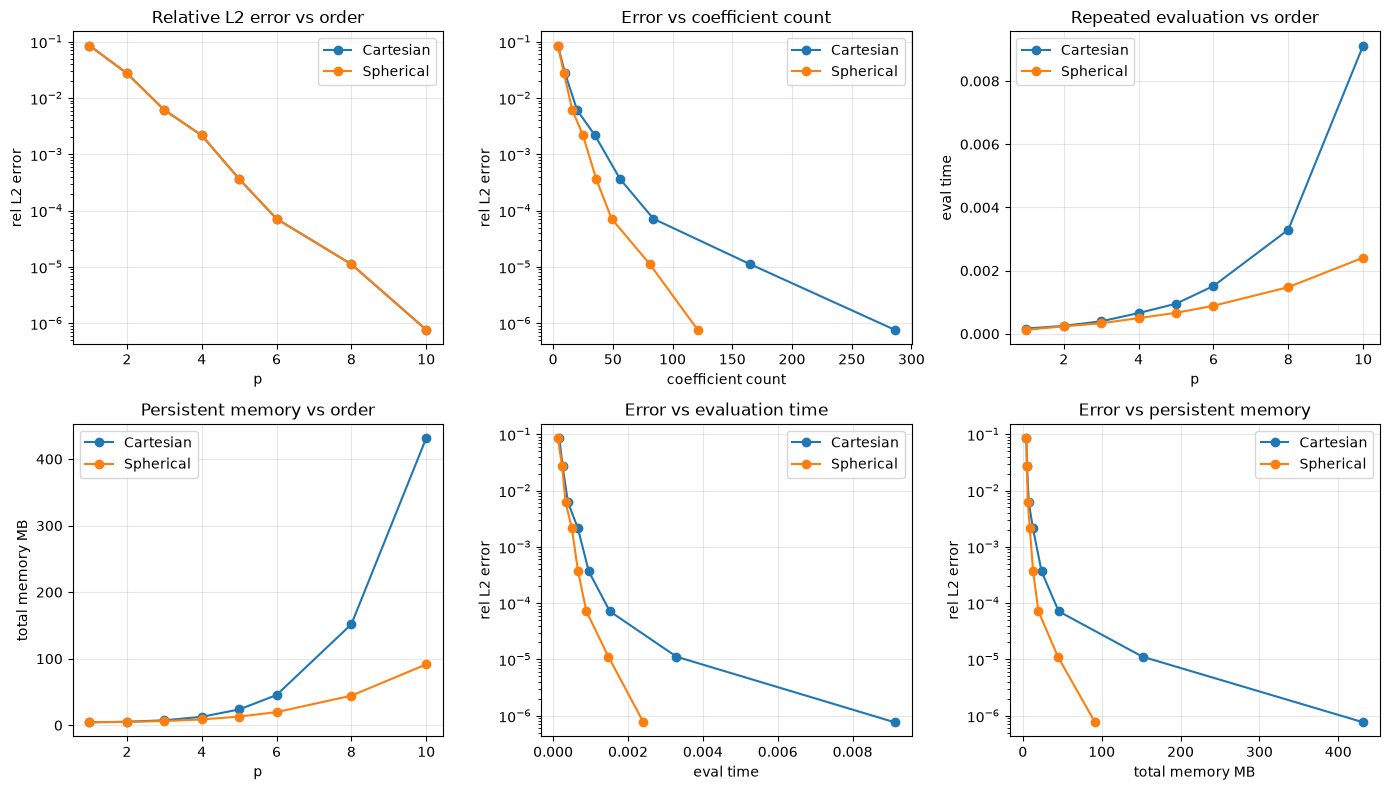

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plots = [
    ('p','rel_L2_error','Relative L2 error vs order'),
    ('coefficient_count','rel_L2_error','Error vs coefficient count'),
    ('p','eval_time','Repeated evaluation vs order'),
    ('p','total_memory_MB','Persistent memory vs order'),
    ('eval_time','rel_L2_error','Error vs evaluation time'),
    ('total_memory_MB','rel_L2_error','Error vs persistent memory'),
]
for axis_plot, (x, y, title) in zip(axes.flat, plots):
    for basis, group in results.groupby('basis'):
        axis_plot.plot(group[x], group[y], 'o-', label=basis)
    axis_plot.set(xlabel=x.replace('_',' '), ylabel=y.replace('_',' '), title=title)
    if 'error' in y: axis_plot.set_yscale('log')
    axis_plot.grid(True, alpha=0.3); axis_plot.legend()
fig.tight_layout()

## Interpretation

The coefficient-count plots compare degrees of freedom more fairly than order alone. P2P and most tree metadata are common to both plans, while P2M/M2M/M2L/L2L/L2P and multipole/local storage change with the basis. `host_memory_MB` reports retained host plan storage, `device_memory_MB` reports the persistent CUDA allocation, and `total_memory_MB` is their sum. Inspect `dominant_stage` and the per-stage columns before deciding whether dense spherical M2L warrants a future FMM3D-style exponential backend.